# 17. IFRA Knowledge Coverage Analysis

현재 향수 추천 프로젝트에서 **IFRA Fragrance Ingredient Glossary (April 2020)**를 향 의미 지식 데이터로 활용할 수 있는지 검증한다.

핵심 질문은 다음과 같다.

> IFRA의 Ingredient / Descriptor 데이터가 Fragrantica 향수 데이터의 Accord와 Note를 실제로 어느 정도 설명할 수 있는가?

이번 노트북은 IFRA 자체 구조와 보수적 직접 연결 범위만 검증한다. LLM, API, embedding, semantic similarity, fuzzy matching, 형태소 기반 확장, 추천 점수화는 사용하지 않는다.


## 0. 분석 목적과 제한사항

- IFRA의 `Principal name`은 실제 fragrance ingredient이고 Fragrantica `Note`는 향을 설명하는 concept이므로 동일 개념으로 가정하지 않는다.
- Primary / Descriptor 2 / Descriptor 3의 순서를 강도나 가중치로 해석하지 않는다.
- Strict match는 대소문자 및 최소 표기 정규화만 허용한다.
- Material family와 제한된 alias는 후보로만 기록하며 strict coverage에 포함하지 않는다.
- 모든 candidate는 `requires_manual_review=True`이다.
- 기존 데이터, 01~16 Notebook, 기존 `analysis_outputs`는 수정하지 않는다.
- edge는 같은 ingredient 행에서 함께 등장한 관계이며 인과관계가 아니다.


## 1. Imports / Paths


In [1]:
import collections
import datetime as dt
import json
import pathlib
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pdfplumber
from IPython.display import Markdown, display

PROJECT_ROOT = pathlib.Path.cwd().resolve()
PDF_PATH = PROJECT_ROOT / "data" / "external" / "ifra" / "raw" / "ifra-fragrance-ingredient-glossary-april-2020.pdf"
PROCESSED_DIR = PROJECT_ROOT / "data" / "external" / "ifra" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "analysis_outputs"
JSONL_PATH = PROJECT_ROOT / "perfumes.jsonl"
CSV_PATH = PROJECT_ROOT / "perfumes.csv"
SCHEMA_PATH = PROJECT_ROOT / "SCHEMA.md"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IFRA_CSV_PATH = PROCESSED_DIR / "ifra_ingredients_2020.csv"
DEFINITION_CSV_PATH = PROCESSED_DIR / "ifra_primary_descriptor_definitions_2020.csv"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (11, 6), "axes.titlesize": 14, "axes.labelsize": 11})

def pct(numerator, denominator):
    return float(numerator / denominator) if denominator else 0.0

def clean_cell(value):
    if value is None:
        return ""
    value = unicodedata.normalize("NFKC", str(value)).replace("\u200b", "").replace("\xad", "")
    return re.sub(r"\s+", " ", value).strip()

def display_table(df, n=20):
    display(df.head(n).style.hide(axis="index"))


## 2. Validate Input Files


In [2]:
required_inputs = [PDF_PATH, JSONL_PATH, CSV_PATH, SCHEMA_PATH]
input_validation_df = pd.DataFrame([
    {"path": str(path.relative_to(PROJECT_ROOT)), "exists": path.exists(), "size_mb": round(path.stat().st_size / 1024**2, 2) if path.exists() else np.nan}
    for path in required_inputs
])
display_table(input_validation_df)
missing_inputs = input_validation_df.loc[~input_validation_df["exists"], "path"].tolist()
assert not missing_inputs, f"Missing required inputs: {missing_inputs}"


path,exists,size_mb
data\external\ifra\raw\ifra-fragrance-ingredient-glossary-april-2020.pdf,True,1.120000
perfumes.jsonl,True,485.940000
perfumes.csv,True,121.430000
SCHEMA.md,True,0.010000


## 3. Inspect IFRA PDF Structure


In [3]:
with pdfplumber.open(PDF_PATH) as pdf:
    page_inspection = []
    for page_index, page in enumerate(pdf.pages):
        text = page.extract_text() or ""
        tables = page.extract_tables()
        page_inspection.append({
            "pdf_page": page_index + 1,
            "text_chars": len(text),
            "table_count": len(tables),
            "has_glossary_header": bool(re.search(r"page\s+\d+/99", text, re.I)),
            "printed_glossary_page": (re.search(r"page\s+(\d+)/99", text, re.I).group(1)
                                      if re.search(r"page\s+(\d+)/99", text, re.I) else ""),
        })
    pdf_page_count = len(pdf.pages)

pdf_structure_df = pd.DataFrame(page_inspection)
glossary_pdf_pages = pdf_structure_df.loc[pdf_structure_df["has_glossary_header"], "pdf_page"].tolist()
first_glossary_pdf_page = min(glossary_pdf_pages)
last_glossary_pdf_page = max(glossary_pdf_pages)

structure_summary_df = pd.DataFrame([
    {"item": "PDF page count", "value": pdf_page_count},
    {"item": "Text extraction available", "value": bool((pdf_structure_df["text_chars"] > 0).all())},
    {"item": "Definition pages (PDF, 1-based)", "value": "7-12"},
    {"item": "Glossary table pages (PDF, 1-based)", "value": f"{first_glossary_pdf_page}-{last_glossary_pdf_page}"},
    {"item": "Glossary table page count", "value": len(glossary_pdf_pages)},
    {"item": "Expected columns", "value": "CAS number | Principal name | Primary descriptor | Descriptor 2 | Descriptor 3"},
])
display_table(structure_summary_df, n=10)
assert pdf_page_count == 111
assert glossary_pdf_pages == list(range(13, 112)), "Glossary pages must be a contiguous 99-page block."


item,value
PDF page count,111
Text extraction available,True
"Definition pages (PDF, 1-based)",7-12
"Glossary table pages (PDF, 1-based)",13-111
Glossary table page count,99
Expected columns,CAS number | Principal name | Primary descriptor | Descriptor 2 | Descriptor 3


## 4. Extract IFRA Tables


In [4]:
raw_rows = []
table_diagnostics = []
updated_markers_removed = 0

with pdfplumber.open(PDF_PATH) as pdf:
    for pdf_page_number in glossary_pdf_pages:
        page = pdf.pages[pdf_page_number - 1]
        tables = page.extract_tables()
        table_diagnostics.append({
            "source_page": pdf_page_number,
            "table_count": len(tables),
            "row_count": sum(len(table) for table in tables),
        })
        if len(tables) != 1:
            raise ValueError(f"Expected one table on PDF page {pdf_page_number}, found {len(tables)}")
        for row_number, row in enumerate(tables[0], start=1):
            if len(row) != 5:
                raise ValueError(f"Expected five cells on PDF page {pdf_page_number}, row {row_number}: {row}")
            cells = [clean_cell(cell) for cell in row]
            if cells[0].startswith("CAS number"):
                continue
            if not any(cells):
                continue
            if cells[1].endswith(" *"):
                cells[1] = cells[1][:-2].rstrip()
                updated_markers_removed += 1
            raw_rows.append({
                "cas_number": cells[0],
                "principal_name": cells[1],
                "primary_descriptor": cells[2],
                "descriptor_2": cells[3],
                "descriptor_3": cells[4],
                "source_page": pdf_page_number,
            })

ifra_df = pd.DataFrame(raw_rows)
ifra_df.insert(0, "ingredient_row_id", np.arange(1, len(ifra_df) + 1))
display_table(ifra_df, n=10)


ingredient_row_id,cas_number,principal_name,primary_descriptor,descriptor_2,descriptor_3,source_page
1,4221-98-1,(-)-(R)-.alpha.-Phellandrene,Aromatic,Medicinal,Citrus,13
2,512-13-0,(-)-.alpha.-Fenchol,Earthy,Woody,Camphoraceous,13
3,489-40-7,(-)-.alpha.-Gurjunene,Woody,Balsamic,Nutty,13
4,23986-74-5,(-)-Germacrene D,Woody,Spicy,Dry,13
5,489-86-1,(-)-Guaiol,Woody,Smoky,Rose,13
6,13837-56-4,"(.+-.)-Tetrahydro-2,6,6-trimethyl-2-vinyl-2H-pyrane",Citrus,Fresh,Camphoraceous,13
7,1117-61-9,(+)-(R)-Citronellol,Floral,Rose,Geranium,13
8,4610-11-1,(+)-cis-Rose oxide,Green,Floral,Rose,13
9,888021-82-7,(+-)-Ethyl 3-mercapto-2-methylbutanoate,Fruity,Food Like,Pungent,13
10,17957-94-7,(+)-Menthofuran,Minty,Leafy,Herbal,13


## 5. Validate Extraction Quality


In [5]:
CAS_PATTERN = re.compile(r"^\d{2,7}-\d{2}-\d(?:\s+\(\d{2,7}-\d{2}-\d\))?$")
data_columns = ["cas_number", "principal_name", "primary_descriptor", "descriptor_2", "descriptor_3"]

missing_counts = {column: int(ifra_df[column].eq("").sum()) for column in data_columns}
cas_valid = ifra_df["cas_number"].str.fullmatch(CAS_PATTERN)
cas_leak_rows = ifra_df[["principal_name", "primary_descriptor", "descriptor_2", "descriptor_3"]].apply(
    lambda col: col.str.contains(r"\b\d{2,7}-\d{2}-\d\b", regex=True)
).any(axis=1)
header_footer_rows = ifra_df.astype(str).apply(
    lambda row: row.str.contains(r"IFRAFRAGRANCE|UPDATE\s*-\s*April|page\s+\d+/99|CAS number", case=False, regex=True).any(),
    axis=1,
)

quality_records = [
    {"metric": "pdf_page_count", "value": pdf_page_count, "notes": "Physical PDF pages"},
    {"metric": "glossary_table_page_count", "value": len(glossary_pdf_pages), "notes": "PDF pages 13-111"},
    {"metric": "total_extracted_rows", "value": len(ifra_df), "notes": "Excludes repeated header"},
    {"metric": "rows_with_missing_cas", "value": missing_counts["cas_number"], "notes": ""},
    {"metric": "rows_with_missing_name", "value": missing_counts["principal_name"], "notes": ""},
    {"metric": "rows_with_missing_primary", "value": missing_counts["primary_descriptor"], "notes": ""},
    {"metric": "rows_with_missing_descriptor2", "value": missing_counts["descriptor_2"], "notes": ""},
    {"metric": "rows_with_missing_descriptor3", "value": missing_counts["descriptor_3"], "notes": ""},
    {"metric": "rows_with_non_5_column_table", "value": 0, "notes": "Extraction stops if detected"},
    {"metric": "rows_with_invalid_cas_format", "value": int((~cas_valid).sum()), "notes": "Allows one parenthesized alternate CAS"},
    {"metric": "rows_with_cas_in_non_cas_column", "value": int(cas_leak_rows.sum()), "notes": "Column-shift diagnostic"},
    {"metric": "header_footer_contamination_rows", "value": int(header_footer_rows.sum()), "notes": ""},
    {"metric": "updated_marker_removed_from_name", "value": updated_markers_removed, "notes": "PDF footnote marker, not part of principal name"},
]
quality_df = pd.DataFrame(quality_records)

known_queries = ["Agarwood oil", "Basil", "alpha-Cedrene"]
known_sample_df = pd.concat([
    ifra_df[ifra_df["principal_name"].str.contains(query, case=False, regex=False)].assign(validation_query=query)
    for query in known_queries
], ignore_index=True)
display_table(known_sample_df[["validation_query", *data_columns, "source_page"]], n=30)

agarwood = ifra_df[ifra_df["principal_name"].str.casefold().eq("agarwood oil")]
cedrene = ifra_df[ifra_df["principal_name"].str.casefold().eq("alpha-cedrene")]
assert not agarwood.empty and (agarwood[["primary_descriptor", "descriptor_2", "descriptor_3"]].iloc[0].tolist() == ["Woody", "Animal Like", "Smoky"])
assert not cedrene.empty and (cedrene[["primary_descriptor", "descriptor_2", "descriptor_3"]].iloc[0].tolist() == ["Woody", "Cedarwood", "Aromatic"])
assert missing_counts == {column: 0 for column in data_columns}
assert cas_valid.all() and not cas_leak_rows.any() and not header_footer_rows.any()

quality_df.to_csv(OUTPUT_DIR / "17_ifra_extraction_quality.csv", index=False, encoding="utf-8-sig")
display_table(quality_df, n=30)


validation_query,cas_number,principal_name,primary_descriptor,descriptor_2,descriptor_3,source_page
Agarwood oil,94350-09-1,Agarwood oil,Woody,Animal Like,Smoky,44
Agarwood oil,1333524-00-7,"Agarwood oil, Indonesia",Woody,Animal Like,Smoky,44
Agarwood oil,958663-49-5,"Agarwood oil, Vietnamese",Woody,Animal Like,Smoky,44
Basil,8015-73-4,"Basil absolute, chemotype linalool",Herbal,Aromatic,Spicy,48
Basil,8015-73-4,"Basil oil, chemotype estragole",Herbal,Aromatic,Green,48
Basil,8015-73-4,"Basil oil, chemotype estragole, rectified",Herbal,Aromatic,Green,48
Basil,8015-73-4,"Basil oil, chemotype linalool",Herbal,Aromatic,Floral,48
Basil,8015-73-4,"Basil oleoresin, chemotype estragole",Herbal,Aromatic,Floral,48
alpha-Cedrene,469-61-4,alpha-Cedrene,Woody,Cedarwood,Aromatic,46


metric,value,notes
pdf_page_count,111,Physical PDF pages
glossary_table_page_count,99,PDF pages 13-111
total_extracted_rows,3119,Excludes repeated header
rows_with_missing_cas,0,
rows_with_missing_name,0,
rows_with_missing_primary,0,
rows_with_missing_descriptor2,0,
rows_with_missing_descriptor3,0,
rows_with_non_5_column_table,0,Extraction stops if detected
rows_with_invalid_cas_format,0,Allows one parenthesized alternate CAS


## 6. Save Processed IFRA Dataset


In [6]:
ifra_export_df = ifra_df[["cas_number", "principal_name", "primary_descriptor", "descriptor_2", "descriptor_3", "source_page"]].copy()
ifra_export_df.to_csv(IFRA_CSV_PATH, index=False, encoding="utf-8-sig")
print(f"Saved {len(ifra_export_df):,} rows -> {IFRA_CSV_PATH.relative_to(PROJECT_ROOT)}")


Saved 3,119 rows -> data\external\ifra\processed\ifra_ingredients_2020.csv


## 7. IFRA Dataset Quality Analysis


In [7]:
cas_counts = ifra_df["cas_number"].value_counts()
name_counts = ifra_df["principal_name"].value_counts()

dataset_quality_df = pd.DataFrame([
    {"metric": "total_rows", "value": len(ifra_df)},
    {"metric": "unique_cas_numbers", "value": ifra_df["cas_number"].nunique()},
    {"metric": "unique_principal_names", "value": ifra_df["principal_name"].nunique()},
    {"metric": "duplicate_cas_values", "value": int((cas_counts > 1).sum())},
    {"metric": "duplicate_cas_rows_beyond_first", "value": int(len(ifra_df) - ifra_df["cas_number"].nunique())},
    {"metric": "duplicate_principal_name_values", "value": int((name_counts > 1).sum())},
    {"metric": "duplicate_principal_name_rows_beyond_first", "value": int(len(ifra_df) - ifra_df["principal_name"].nunique())},
    {"metric": "cas_with_multiple_principal_names", "value": int((ifra_df.groupby("cas_number")["principal_name"].nunique() > 1).sum())},
    {"metric": "principal_names_with_multiple_cas", "value": int((ifra_df.groupby("principal_name")["cas_number"].nunique() > 1).sum())},
    {"metric": "exact_duplicate_rows", "value": int(ifra_df.duplicated(data_columns).sum())},
])
display_table(dataset_quality_df, n=20)

multi_name_cas_df = (ifra_df.groupby("cas_number")["principal_name"].agg(lambda values: " | ".join(sorted(set(values))))
                     .reset_index(name="principal_names"))
multi_name_cas_df = multi_name_cas_df[multi_name_cas_df["principal_names"].str.contains(r"\|")]
display_table(multi_name_cas_df, n=10)


metric,value
total_rows,3119
unique_cas_numbers,2588
unique_principal_names,3094
duplicate_cas_values,176
duplicate_cas_rows_beyond_first,531
duplicate_principal_name_values,25
duplicate_principal_name_rows_beyond_first,25
cas_with_multiple_principal_names,176
principal_names_with_multiple_cas,6
exact_duplicate_rows,18


cas_number,principal_names
1005328-84-6,"Procavia capensis extract | Procavia capensis, tincture"
102242-62-6,Lemon pepper CO2 Extract | Lemon pepper extract | Sichuan pepper CO2 extract | Zanthoxylum piperitum extract
1034798-23-6,Jasmine sambac CO2 extract | Jasmine sambac absolute | Jasmine sambac oil | Jasmine sambac tincture
1048028-77-8,Iris germanica CO2 extract | Iris germanica absolute | Iris germanica concrete | Iris germanica extract | Iris germanica resinoid
1069136-34-0,"Callitropsis nootkatensis oil | Callitropsis nootkatensis oil, rectified"
1070895-66-7,"Sandalwood absolute | Sandalwood extract | Sandalwood oil, rectified"
1159574-01-2,"Cedarwood oil, Chinese | Cedarwood oil, Chinese, rectified | Cedarwood terpenes, Chinese"
39900-38-4,Cedrenyl formate | Cedryl formate
683748-01-8,Gardenia tahitensis absolute | Gardenia tahitensis oil
68606-82-6,Deer tongue pyrogenated | Deertongue leaf absolute | Deertongue leaf extract | Deertongue leaf incolore


## 8. Primary Descriptor Analysis


In [8]:
def canonical_display(value):
    value = re.sub(r"[-_]+", " ", clean_cell(value)).strip()
    return " ".join(part.capitalize() for part in value.split())

ifra_df["primary_canonical"] = ifra_df["primary_descriptor"].map(canonical_display)
primary_distribution_df = ifra_df["primary_canonical"].value_counts().rename_axis("primary_descriptor").reset_index(name="count")
primary_distribution_df["percentage"] = primary_distribution_df["count"] / len(ifra_df)
primary_distribution_df.to_csv(OUTPUT_DIR / "17_ifra_primary_descriptor_distribution.csv", index=False, encoding="utf-8-sig")
display_table(primary_distribution_df, n=30)


primary_descriptor,count,percentage
Floral,613,0.196537
Fruity,488,0.156460
Woody,330,0.105803
Herbal,284,0.091055
Green,248,0.079513
Citrus,222,0.071177
Spicy,183,0.058673
Gourmand,113,0.036230
Balsamic,71,0.022764
Minty,69,0.022122


## 9. Secondary Descriptor Analysis


In [9]:
secondary_long_df = ifra_df.melt(
    id_vars=["ingredient_row_id"], value_vars=["descriptor_2", "descriptor_3"],
    var_name="source_column", value_name="raw_secondary_descriptor"
)
secondary_long_df["secondary_descriptor"] = secondary_long_df["raw_secondary_descriptor"].map(canonical_display)

secondary_distribution_df = (
    secondary_long_df.groupby("secondary_descriptor")
    .agg(
        count=("ingredient_row_id", "size"),
        ingredient_count=("ingredient_row_id", "nunique"),
        descriptor_2_count=("source_column", lambda s: int((s == "descriptor_2").sum())),
        descriptor_3_count=("source_column", lambda s: int((s == "descriptor_3").sum())),
    )
    .reset_index()
    .sort_values(["count", "secondary_descriptor"], ascending=[False, True])
)
secondary_distribution_df["percentage"] = secondary_distribution_df["count"] / len(secondary_long_df)
secondary_distribution_df = secondary_distribution_df[[
    "secondary_descriptor", "count", "percentage", "ingredient_count", "descriptor_2_count", "descriptor_3_count"
]]
secondary_distribution_df.to_csv(OUTPUT_DIR / "17_ifra_secondary_descriptor_distribution.csv", index=False, encoding="utf-8-sig")

secondary_vocab_stats_df = pd.DataFrame([
    {"metric": "descriptor_2_unique", "value": ifra_df["descriptor_2"].map(canonical_display).nunique()},
    {"metric": "descriptor_3_unique", "value": ifra_df["descriptor_3"].map(canonical_display).nunique()},
    {"metric": "descriptor_2_3_union_unique", "value": secondary_long_df["secondary_descriptor"].nunique()},
])
display_table(secondary_vocab_stats_df)
display_table(secondary_distribution_df, n=30)


metric,value
descriptor_2_unique,184
descriptor_3_unique,204
descriptor_2_3_union_unique,228


secondary_descriptor,count,percentage,ingredient_count,descriptor_2_count,descriptor_3_count
Green,434,0.069574,434,177,257
Sweet,352,0.056428,352,224,128
Floral,329,0.052741,329,156,173
Fresh,304,0.048734,304,178,126
Fruity,276,0.044245,276,135,141
Herbal,200,0.032062,200,88,112
Woody,197,0.031581,197,88,109
Rose,180,0.028855,180,130,50
Citrus,135,0.021642,135,49,86
Balsamic,133,0.021321,133,67,66


## 10. Primary-Secondary Relationship Analysis


In [10]:
edge_df = secondary_long_df.merge(ifra_df[["ingredient_row_id", "primary_canonical"]], on="ingredient_row_id", how="left")
descriptor_edges_df = (
    edge_df.groupby(["primary_canonical", "secondary_descriptor"]).size()
    .reset_index(name="count")
    .rename(columns={"primary_canonical": "primary_descriptor"})
    .sort_values(["count", "primary_descriptor", "secondary_descriptor"], ascending=[False, True, True])
)
descriptor_edges_df.to_csv(OUTPUT_DIR / "17_ifra_descriptor_edges.csv", index=False, encoding="utf-8-sig")

secondary_primary_profile_df = descriptor_edges_df.copy()
secondary_primary_profile_df["share"] = secondary_primary_profile_df["count"] / secondary_primary_profile_df.groupby("secondary_descriptor")["count"].transform("sum")
secondary_primary_profile_df = secondary_primary_profile_df[["secondary_descriptor", "primary_descriptor", "count", "share"]]
secondary_primary_profile_df = secondary_primary_profile_df.sort_values(["secondary_descriptor", "count", "primary_descriptor"], ascending=[True, False, True])
secondary_primary_profile_df.to_csv(OUTPUT_DIR / "17_ifra_secondary_primary_profile.csv", index=False, encoding="utf-8-sig")

display_table(descriptor_edges_df, n=25)


primary_descriptor,secondary_descriptor,count
Floral,Rose,145
Floral,Green,144
Fruity,Green,114
Fruity,Sweet,91
Floral,Fruity,83
Floral,Sweet,82
Green,Floral,76
Fruity,Apple,74
Floral,Jasmin,68
Citrus,Fresh,63


## 11. Extract Primary Descriptor Definitions


In [11]:
HEADING_PATTERN = re.compile(r"^[A-Z][A-Z\- ]+$")
definition_rows = []

with pdfplumber.open(PDF_PATH) as pdf:
    for pdf_page_number in range(7, 13):
        lines = [clean_cell(line) for line in (pdf.pages[pdf_page_number - 1].extract_text() or "").splitlines()]
        current_heading = None
        current_definition = []
        for line in lines:
            if not line or line in {"DECODING THE GLOSSARY", "IFRAFRAGRANCE.ORG/GLOSSARY"} or re.fullmatch(r"[ivx]+", line):
                continue
            if line.startswith("To enhance clarity") or (current_heading is None and line.startswith("have developed")):
                continue
            if HEADING_PATTERN.fullmatch(line):
                if current_heading is not None:
                    definition_rows.append({"descriptor": current_heading.title(), "definition": " ".join(current_definition), "source_page": pdf_page_number})
                current_heading = line
                current_definition = []
            elif current_heading is not None:
                current_definition.append(line)
        if current_heading is not None:
            definition_rows.append({"descriptor": current_heading.title(), "definition": " ".join(current_definition), "source_page": pdf_page_number})

definitions_df = pd.DataFrame(definition_rows)
definitions_df.to_csv(DEFINITION_CSV_PATH, index=False, encoding="utf-8-sig")

def conservative_normalize(value):
    value = unicodedata.normalize("NFKC", clean_cell(value)).casefold()
    value = re.sub(r"[-_]+", " ", value)
    value = re.sub(r"[^\w\s]", " ", value)
    return re.sub(r"\s+", " ", value).strip()

definition_norms = set(definitions_df["descriptor"].map(conservative_normalize))
primary_norms = set(ifra_df["primary_descriptor"].map(conservative_normalize))
assert len(definitions_df) == 27 and definitions_df["descriptor"].nunique() == 27
assert definition_norms == primary_norms, f"Definition/table mismatch: {sorted(definition_norms ^ primary_norms)}"
display_table(definitions_df, n=30)


descriptor,definition,source_page
Acidic,Acidic means a fragrance note that smells sharp and somewhat pungent. Acidic notes may help boost a citrus note or impart natural qualities.,7
Aldehydic,"Aldehydes vary: the more diluted they become, the greater the difference in smell. An overarching description is one of clean ironed linen. Aldehydes can be split into more specific profiles, such as citrus or ozonic. They are organic compounds found in natural oils (e.g. orange oil or rose oil) and are used at relatively low doses.",7
Amber,"Amber is used to describe a complex note in fragrances that are a mixture of warm, woody and sweet notes that impart a rich and comforting character.",7
Animal-Like,"Animal-like notes are important notes used in perfumery. They do not come from animals, but are created to give what some would see as a faecal note or a musk note. In dilution they might help impart musk notes or floral notes like jasmin.",7
Anisic,Anisic materials are those that smell similar to natural aniseed materials like tarragon or fennel.,8
Aromatic,"Aromatic notes are complex notes that are sometimes also described as having a diffusive aroma. They may be recognized in cooking as culinary herbs and spices, but they have a full fragrance quality.",8
Balsamic,"Ingredients that smell balsamic tend to have a delicate smell that is slightly sweet and woody, and have been termed using natural resins and balsams exuded by some trees or shrubs.",8
Camphoraceous,"A fresh, strong and diffusive smell that is characterized by natural camphor and other herbs such as rosemary or marjoram.",8
Citrus,"Citrus notes are given by the smell of fruit from the citrus family – such as orange, lemon or grapefruit.",8
Earthy,Earthy notes are reminiscent of earth and mud. They are important when creating a fragrance that needs to impart the full character of a living flower or to give natural outdoor notes – allowing the creation of full landscape (e.g. a bed of roses on a wet day) as opposed to a single or specific smell.,9


## 12. Load Fragrantica Schema


In [12]:
schema_text = SCHEMA_PATH.read_text(encoding="utf-8", errors="replace")
schema_checks_df = pd.DataFrame([
    {"schema_item": "accords", "confirmed": '"accords"' in schema_text or "accords[]" in schema_text, "used_fields": "name, strength"},
    {"schema_item": "notes.tiered", "confirmed": '"tiered"' in schema_text or "notes[]." in schema_text, "used_fields": "top, middle, base"},
    {"schema_item": "notes.flat", "confirmed": '"flat"' in schema_text or "tiered XOR flat" in schema_text, "used_fields": "flat"},
])
display_table(schema_checks_df)
assert schema_checks_df["confirmed"].all()


schema_item,confirmed,used_fields
accords,True,"name, strength"
notes.tiered,True,"top, middle, base"
notes.flat,True,flat


## 13. Build Accord Vocabulary


In [13]:
accord_occurrence = collections.Counter()
accord_perfume = collections.Counter()
note_occurrence = collections.Counter()
note_perfume = collections.Counter()
total_perfumes = 0
perfumes_with_any_note = 0

with JSONL_PATH.open("r", encoding="utf-8") as stream:
    for line_number, line in enumerate(stream, start=1):
        record = json.loads(line)
        total_perfumes += 1

        accords = [clean_cell(item.get("name", "")) for item in record.get("accords", []) if clean_cell(item.get("name", ""))]
        accord_occurrence.update(accords)
        accord_perfume.update(set(accords))

        notes = record.get("notes", {}) or {}
        tiered = notes.get("tiered", {}) or {}
        note_names = []
        for tier in ("top", "middle", "base"):
            note_names.extend(clean_cell(item.get("name", "")) for item in (tiered.get(tier, []) or []) if clean_cell(item.get("name", "")))
        note_names.extend(clean_cell(item.get("name", "")) for item in (notes.get("flat", []) or []) if clean_cell(item.get("name", "")))
        note_occurrence.update(note_names)
        note_perfume.update(set(note_names))
        perfumes_with_any_note += bool(note_names)

accord_vocab_df = pd.DataFrame([
    {"accord": name, "perfume_count": accord_perfume[name], "occurrence_count": count}
    for name, count in accord_occurrence.items()
]).sort_values(["perfume_count", "occurrence_count", "accord"], ascending=[False, False, True]).reset_index(drop=True)
accord_vocab_df.to_csv(OUTPUT_DIR / "17_fragrantica_accord_vocabulary.csv", index=False, encoding="utf-8-sig")

print(f"Perfumes: {total_perfumes:,} | Unique accords: {len(accord_vocab_df):,}")
display_table(accord_vocab_df, n=30)


Perfumes: 131,930 | Unique accords: 92


accord,perfume_count,occurrence_count
woody,81432,81432
powdery,62885,62885
sweet,60625,60625
citrus,59969,59969
aromatic,54606,54606
fresh spicy,47271,47271
floral,46586,46586
amber,45478,45478
warm spicy,45319,45319
fruity,43222,43222


## 14. Build Note Vocabulary


In [14]:
note_vocab_df = pd.DataFrame([
    {"note": name, "perfume_count": note_perfume[name], "occurrence_count": count}
    for name, count in note_occurrence.items()
]).sort_values(["perfume_count", "occurrence_count", "note"], ascending=[False, False, True]).reset_index(drop=True)
note_vocab_df.to_csv(OUTPUT_DIR / "17_fragrantica_note_vocabulary.csv", index=False, encoding="utf-8-sig")

print(f"Unique notes: {len(note_vocab_df):,} | Perfumes with any note: {perfumes_with_any_note:,}")
display_table(note_vocab_df, n=30)


Unique notes: 2,523 | Perfumes with any note: 129,388


note,perfume_count,occurrence_count
Musk,49244,49571
Amber,36671,36972
Bergamot,36337,36364
Vanilla,35628,36042
Sandalwood,34292,34458
Jasmine,33686,33952
Patchouli,32473,32676
Rose,27804,28270
Cedar,22305,22502
Vetiver,17674,17746


## 15. Define Conservative Normalization


In [15]:
# conservative_normalize was defined in section 11 and is intentionally limited to:
# lowercase/casefold, strip, whitespace collapse, hyphen/underscore/space unification,
# Unicode NFKC, and simple punctuation removal.
# No stemming, lemmatization, fuzzy matching, embeddings, or semantic expansion.

normalization_examples_df = pd.DataFrame({
    "raw": ["Musk-like", "Musk like", "Food_Like", "  fresh   spicy  ", "Lily-of-the-Valley"],
})
normalization_examples_df["normalized"] = normalization_examples_df["raw"].map(conservative_normalize)
display_table(normalization_examples_df)


raw,normalized
Musk-like,musk like
Musk like,musk like
Food_Like,food like
fresh spicy,fresh spicy
Lily-of-the-Valley,lily of the valley


## 16. Accord Strict Matching


In [16]:
def build_lookup(values, normalizer):
    lookup = collections.defaultdict(list)
    for value in values:
        key = normalizer(value)
        if value not in lookup[key]:
            lookup[key].append(value)
    return lookup

exact_key = lambda value: clean_cell(value).casefold()

principal_exact_lookup = build_lookup(ifra_df["principal_name"].unique(), exact_key)
principal_norm_lookup = build_lookup(ifra_df["principal_name"].unique(), conservative_normalize)
primary_exact_lookup = build_lookup(ifra_df["primary_descriptor"].unique(), exact_key)
primary_norm_lookup = build_lookup(ifra_df["primary_descriptor"].unique(), conservative_normalize)
secondary_values = pd.unique(ifra_df[["descriptor_2", "descriptor_3"]].values.ravel()).tolist()
secondary_exact_lookup = build_lookup(secondary_values, exact_key)
secondary_norm_lookup = build_lookup(secondary_values, conservative_normalize)

ALIAS_RULES = {
    "oud": ("Agarwood", "common perfume-note synonym"),
    "agarwood oud": ("Agarwood", "parenthetical synonym candidate"),
    "cedar": ("Cedarwood", "short-form candidate"),
    "musk": ("Musk Like", "concept-to-descriptor candidate"),
    "musky": ("Musk Like", "adjectival-form candidate"),
    "animalic": ("Animal Like", "common descriptor wording candidate"),
    "tobacco": ("Tobacco Like", "concept-to-descriptor candidate"),
}

def strict_descriptor_match(feature):
    exact = exact_key(feature)
    norm = conservative_normalize(feature)
    if exact in primary_exact_lookup:
        return "MATCH_EXACT_PRIMARY", primary_exact_lookup[exact][0], "PRIMARY"
    if exact in secondary_exact_lookup:
        return "MATCH_EXACT_SECONDARY", secondary_exact_lookup[exact][0], "SECONDARY"
    if norm in primary_norm_lookup:
        return "MATCH_NORMALIZED_PRIMARY", primary_norm_lookup[norm][0], "PRIMARY"
    if norm in secondary_norm_lookup:
        return "MATCH_NORMALIZED_SECONDARY", secondary_norm_lookup[norm][0], "SECONDARY"
    return "UNMATCHED", "", ""

accord_match_rows = []
for row in accord_vocab_df.itertuples(index=False):
    status, term, level = strict_descriptor_match(row.accord)
    alias = ALIAS_RULES.get(conservative_normalize(row.accord))
    alias_candidate = alias[0] if status == "UNMATCHED" and alias else ""
    accord_match_rows.append({
        "accord": row.accord,
        "perfume_count": row.perfume_count,
        "occurrence_count": row.occurrence_count,
        "match_status": status,
        "matched_ifra_term": term,
        "matched_ifra_level": level,
        "alias_candidate": alias_candidate,
        "notes": alias[1] if alias_candidate else "",
    })

accord_matching_df = pd.DataFrame(accord_match_rows)
accord_matching_df.to_csv(OUTPUT_DIR / "17_accord_ifra_matching.csv", index=False, encoding="utf-8-sig")
display_table(accord_matching_df, n=100)


accord,perfume_count,occurrence_count,match_status,matched_ifra_term,matched_ifra_level,alias_candidate,notes
woody,81432,81432,MATCH_EXACT_PRIMARY,Woody,PRIMARY,,
powdery,62885,62885,MATCH_EXACT_PRIMARY,Powdery,PRIMARY,,
sweet,60625,60625,MATCH_EXACT_SECONDARY,Sweet,SECONDARY,,
citrus,59969,59969,MATCH_EXACT_PRIMARY,Citrus,PRIMARY,,
aromatic,54606,54606,MATCH_EXACT_PRIMARY,Aromatic,PRIMARY,,
fresh spicy,47271,47271,UNMATCHED,,,,
floral,46586,46586,MATCH_EXACT_PRIMARY,Floral,PRIMARY,,
amber,45478,45478,MATCH_EXACT_PRIMARY,Amber,PRIMARY,,
warm spicy,45319,45319,UNMATCHED,,,,
fruity,43222,43222,MATCH_EXACT_PRIMARY,Fruity,PRIMARY,,


## 17. Accord Coverage


In [17]:
accord_matching_df["strict_match"] = accord_matching_df["match_status"].ne("UNMATCHED")
accord_matching_df["potential_match"] = accord_matching_df["strict_match"] | accord_matching_df["alias_candidate"].ne("")

total_accords = len(accord_matching_df)
strict_matched_accords = int(accord_matching_df["strict_match"].sum())
potential_matched_accords = int(accord_matching_df["potential_match"].sum())
strict_accord_vocabulary_coverage = pct(strict_matched_accords, total_accords)
potential_accord_coverage = pct(potential_matched_accords, total_accords)
accord_occurrence_weighted_coverage = pct(
    accord_matching_df.loc[accord_matching_df["strict_match"], "occurrence_count"].sum(),
    accord_matching_df["occurrence_count"].sum(),
)

accord_level_summary_df = pd.DataFrame([
    {"category": "Primary match", "count": int((accord_matching_df["matched_ifra_level"] == "PRIMARY").sum())},
    {"category": "Secondary-only match", "count": int((accord_matching_df["matched_ifra_level"] == "SECONDARY").sum())},
    {"category": "Unmatched", "count": int((accord_matching_df["match_status"] == "UNMATCHED").sum())},
])
accord_level_summary_df["share"] = accord_level_summary_df["count"] / total_accords
display_table(accord_level_summary_df)


category,count,share
Primary match,17,0.184783
Secondary-only match,31,0.336957
Unmatched,44,0.478261


## 18. Note Strict Matching


In [18]:
def strict_note_match(note):
    exact = exact_key(note)
    norm = conservative_normalize(note)
    if exact in principal_exact_lookup:
        return "MATCH_PRINCIPAL_EXACT", principal_exact_lookup[exact][0], "PRINCIPAL"
    if norm in principal_norm_lookup:
        return "MATCH_PRINCIPAL_NORMALIZED", principal_norm_lookup[norm][0], "PRINCIPAL"
    if exact in primary_exact_lookup or norm in primary_norm_lookup:
        term = (primary_exact_lookup.get(exact) or primary_norm_lookup.get(norm))[0]
        return "MATCH_PRIMARY_DESCRIPTOR", term, "PRIMARY_DESCRIPTOR"
    if exact in secondary_exact_lookup or norm in secondary_norm_lookup:
        term = (secondary_exact_lookup.get(exact) or secondary_norm_lookup.get(norm))[0]
        return "MATCH_SECONDARY_DESCRIPTOR", term, "SECONDARY_DESCRIPTOR"
    return "UNMATCHED", "", ""

note_match_rows = []
for row in note_vocab_df.itertuples(index=False):
    status, term, level = strict_note_match(row.note)
    note_match_rows.append({
        "note": row.note,
        "perfume_count": row.perfume_count,
        "occurrence_count": row.occurrence_count,
        "strict_match_status": status,
        "strict_matched_term": term,
        "strict_ifra_level": level,
    })

note_matching_df = pd.DataFrame(note_match_rows)
print(note_matching_df["strict_match_status"].value_counts().to_string())


strict_match_status
UNMATCHED                     2364
MATCH_SECONDARY_DESCRIPTOR     119
MATCH_PRINCIPAL_EXACT           37
MATCH_PRIMARY_DESCRIPTOR         3


## 19. Material Family Candidate Analysis


In [19]:
MATERIAL_FORM_PATTERN = re.compile(
    r"^(?P<base>.+?)\s+(?:CO2\s+extract|absolute|oil|extract|tincture|resinoid|oleoresin|distillate|essence|concrete)(?:\b.*)?$",
    re.IGNORECASE,
)

material_base_lookup = collections.defaultdict(list)
for principal_name in ifra_df["principal_name"].unique():
    match = MATERIAL_FORM_PATTERN.match(principal_name)
    if not match:
        continue
    base = clean_cell(match.group("base"))
    base_norm = conservative_normalize(base)
    if principal_name not in material_base_lookup[base_norm]:
        material_base_lookup[base_norm].append(principal_name)

def material_family_candidates(note):
    note_norm = conservative_normalize(note)
    candidates = list(material_base_lookup.get(note_norm, []))
    if not candidates:
        for base_norm, names in material_base_lookup.items():
            if base_norm.startswith(note_norm + " "):
                candidates.extend(names)
    return candidates

material_candidate_values = []
for row in note_matching_df.itertuples(index=False):
    if row.strict_match_status != "UNMATCHED":
        material_candidate_values.append("")
        continue
    candidates = material_family_candidates(row.note)
    material_candidate_values.append(" | ".join(candidates[:10]))

note_matching_df["material_family_candidate"] = material_candidate_values
print(f"Non-strict notes with a material-family candidate: {(note_matching_df['material_family_candidate'] != '').sum():,}")


Non-strict notes with a material-family candidate: 98

## 20. Alias Candidate Analysis


In [20]:
note_alias_values = []
for row in note_matching_df.itertuples(index=False):
    alias = ALIAS_RULES.get(conservative_normalize(row.note))
    note_alias_values.append(alias[0] if row.strict_match_status == "UNMATCHED" and alias else "")
note_matching_df["alias_candidate"] = note_alias_values

alias_rows = []
for row in accord_matching_df.itertuples(index=False):
    if row.alias_candidate:
        alias_rows.append({
            "fragrantica_feature": row.accord,
            "feature_type": "accord",
            "ifra_candidate": row.alias_candidate,
            "candidate_reason": row.notes,
            "requires_manual_review": True,
        })
for row in note_matching_df.itertuples(index=False):
    if row.alias_candidate:
        reason = ALIAS_RULES[conservative_normalize(row.note)][1]
        alias_rows.append({
            "fragrantica_feature": row.note,
            "feature_type": "note",
            "ifra_candidate": row.alias_candidate,
            "candidate_reason": reason,
            "requires_manual_review": True,
        })

alias_candidates_df = pd.DataFrame(alias_rows, columns=[
    "fragrantica_feature", "feature_type", "ifra_candidate", "candidate_reason", "requires_manual_review"
])
alias_candidates_df.to_csv(OUTPUT_DIR / "17_ifra_alias_candidates.csv", index=False, encoding="utf-8-sig")
display_table(alias_candidates_df, n=30)


fragrantica_feature,feature_type,ifra_candidate,candidate_reason,requires_manual_review
musky,accord,Musk Like,adjectival-form candidate,True
animalic,accord,Animal Like,common descriptor wording candidate,True
oud,accord,Agarwood,common perfume-note synonym,True
Musk,note,Musk Like,concept-to-descriptor candidate,True
Cedar,note,Cedarwood,short-form candidate,True
Agarwood (Oud),note,Agarwood,parenthetical synonym candidate,True
Oud,note,Agarwood,common perfume-note synonym,True


## 21. Note Coverage


In [21]:
note_matching_df["final_auto_status"] = np.select(
    [
        note_matching_df["strict_match_status"].ne("UNMATCHED"),
        note_matching_df["material_family_candidate"].ne("") | note_matching_df["alias_candidate"].ne(""),
    ],
    ["STRICT_MATCH", "CANDIDATE_ONLY"],
    default="UNMATCHED",
)
note_matching_df.to_csv(OUTPUT_DIR / "17_note_ifra_matching.csv", index=False, encoding="utf-8-sig")

total_notes = len(note_matching_df)
strict_matched_notes = int(note_matching_df["final_auto_status"].eq("STRICT_MATCH").sum())
potential_matched_notes = int(note_matching_df["final_auto_status"].ne("UNMATCHED").sum())
strict_note_vocabulary_coverage = pct(strict_matched_notes, total_notes)
potential_note_coverage = pct(potential_matched_notes, total_notes)
strict_note_occurrence_weighted_coverage = pct(
    note_matching_df.loc[note_matching_df["final_auto_status"].eq("STRICT_MATCH"), "occurrence_count"].sum(),
    note_matching_df["occurrence_count"].sum(),
)

strict_note_norms = set(note_matching_df.loc[note_matching_df["final_auto_status"].eq("STRICT_MATCH"), "note"].map(conservative_normalize))
perfumes_with_at_least_one_strict_matched_note = 0
with JSONL_PATH.open("r", encoding="utf-8") as stream:
    for line in stream:
        record = json.loads(line)
        notes = record.get("notes", {}) or {}
        tiered = notes.get("tiered", {}) or {}
        perfume_notes = []
        for tier in ("top", "middle", "base"):
            perfume_notes.extend(item.get("name", "") for item in (tiered.get(tier, []) or []))
        perfume_notes.extend(item.get("name", "") for item in (notes.get("flat", []) or []))
        if any(conservative_normalize(note) in strict_note_norms for note in perfume_notes):
            perfumes_with_at_least_one_strict_matched_note += 1

perfume_level_note_coverage = pct(perfumes_with_at_least_one_strict_matched_note, total_perfumes)

note_coverage_summary_df = pd.DataFrame([
    {"metric": "strict_note_vocabulary_coverage", "value": strict_note_vocabulary_coverage},
    {"metric": "potential_note_coverage", "value": potential_note_coverage},
    {"metric": "strict_note_occurrence_weighted_coverage", "value": strict_note_occurrence_weighted_coverage},
    {"metric": "perfume_level_note_coverage", "value": perfume_level_note_coverage},
])
display_table(note_coverage_summary_df)


metric,value
strict_note_vocabulary_coverage,0.063020
potential_note_coverage,0.103052
strict_note_occurrence_weighted_coverage,0.497042
perfume_level_note_coverage,0.923111


## 22. Frequency-weighted Coverage


In [22]:
frequency_coverage_df = pd.DataFrame([
    {"feature_type": "accord", "vocabulary_coverage": strict_accord_vocabulary_coverage, "occurrence_weighted_coverage": accord_occurrence_weighted_coverage},
    {"feature_type": "note", "vocabulary_coverage": strict_note_vocabulary_coverage, "occurrence_weighted_coverage": strict_note_occurrence_weighted_coverage},
])
display_table(frequency_coverage_df)


feature_type,vocabulary_coverage,occurrence_weighted_coverage
accord,0.521739,0.740829
note,0.063020,0.497042


## 23. Top-N Note Coverage


In [23]:
top_note_coverage_rows = []
for requested_n in [20, 50, 100, 200, 500]:
    top_df = note_matching_df.nlargest(requested_n, ["perfume_count", "occurrence_count"])
    strict_mask = top_df["final_auto_status"].eq("STRICT_MATCH")
    top_note_coverage_rows.append({
        "top_n": requested_n,
        "available_notes": len(top_df),
        "strict_matched_notes": int(strict_mask.sum()),
        "strict_vocabulary_coverage": pct(strict_mask.sum(), len(top_df)),
        "strict_occurrence_weighted_coverage": pct(top_df.loc[strict_mask, "occurrence_count"].sum(), top_df["occurrence_count"].sum()),
    })

top_note_coverage_df = pd.DataFrame(top_note_coverage_rows)
top_note_coverage_df.to_csv(OUTPUT_DIR / "17_ifra_top_note_coverage.csv", index=False, encoding="utf-8-sig")
display_table(top_note_coverage_df)


top_n,available_notes,strict_matched_notes,strict_vocabulary_coverage,strict_occurrence_weighted_coverage
20,20,11,0.550000,0.606628
50,50,30,0.600000,0.617265
100,100,55,0.550000,0.596329
200,200,88,0.440000,0.561002
500,500,115,0.230000,0.514577


## 24. Representative Match Cases


In [24]:
representative_targets = [
    "Musk", "Amber", "Bergamot", "Vanilla", "Sandalwood", "Jasmine", "Patchouli",
    "Rose", "Cedar", "Vetiver", "Pine", "Basil", "Agarwood", "Oud", "Agarwood (Oud)",
]
representative_cases_df = note_matching_df[note_matching_df["note"].str.casefold().isin({x.casefold() for x in representative_targets})].copy()
representative_cases_df = representative_cases_df[[
    "note", "perfume_count", "strict_match_status", "strict_matched_term", "strict_ifra_level",
    "material_family_candidate", "alias_candidate", "final_auto_status",
]].sort_values("perfume_count", ascending=False)
display_table(representative_cases_df, n=30)


note,perfume_count,strict_match_status,strict_matched_term,strict_ifra_level,material_family_candidate,alias_candidate,final_auto_status
Musk,49244,UNMATCHED,,,,Musk Like,CANDIDATE_ONLY
Amber,36671,MATCH_PRIMARY_DESCRIPTOR,Amber,PRIMARY_DESCRIPTOR,,,STRICT_MATCH
Bergamot,36337,MATCH_SECONDARY_DESCRIPTOR,Bergamot,SECONDARY_DESCRIPTOR,,,STRICT_MATCH
Vanilla,35628,MATCH_SECONDARY_DESCRIPTOR,Vanilla,SECONDARY_DESCRIPTOR,,,STRICT_MATCH
Sandalwood,34292,MATCH_SECONDARY_DESCRIPTOR,Sandalwood,SECONDARY_DESCRIPTOR,,,STRICT_MATCH
Jasmine,33686,UNMATCHED,,,Jasmine absolute | Jasmine CO2 extract | Jasmine concrete | Jasmine concrete (waxes twice extracted) | Jasmine oil,,CANDIDATE_ONLY
Patchouli,32473,MATCH_PRINCIPAL_EXACT,Patchouli,PRINCIPAL,,,STRICT_MATCH
Rose,27804,MATCH_PRINCIPAL_EXACT,Rose,PRINCIPAL,,,STRICT_MATCH
Cedar,22305,UNMATCHED,,,"Cedar leaf oil | Cedar leaf oil, China | Cedar leaf oil, East Canada | Cedar leaf oil, rectified",Cedarwood,CANDIDATE_ONLY
Vetiver,17674,MATCH_SECONDARY_DESCRIPTOR,Vetiver,SECONDARY_DESCRIPTOR,,,STRICT_MATCH


## 25. Top Unmatched Notes


In [25]:
top_unmatched_notes_df = (
    note_matching_df[note_matching_df["final_auto_status"].eq("UNMATCHED")]
    .sort_values(["perfume_count", "occurrence_count", "note"], ascending=[False, False, True])
    .head(100)
    [["note", "perfume_count", "occurrence_count", "strict_match_status", "final_auto_status"]]
)
top_unmatched_notes_df.to_csv(OUTPUT_DIR / "17_top_unmatched_notes.csv", index=False, encoding="utf-8-sig")
display_table(top_unmatched_notes_df, n=30)


note,perfume_count,occurrence_count,strict_match_status,final_auto_status
Mandarin Orange,11646,11652,UNMATCHED,UNMATCHED
Orange Blossom,11479,11545,UNMATCHED,UNMATCHED
Leather,10626,10754,UNMATCHED,UNMATCHED
Pink Pepper,10387,10395,UNMATCHED,UNMATCHED
White Musk,8339,8371,UNMATCHED,UNMATCHED
Woody Notes,8278,8385,UNMATCHED,UNMATCHED
Lily-of-the-Valley,7339,7366,UNMATCHED,UNMATCHED
Freesia,5683,5696,UNMATCHED,UNMATCHED
Black Currant,5560,5566,UNMATCHED,UNMATCHED
Citruses,4982,4993,UNMATCHED,UNMATCHED


## 26. Visualizations


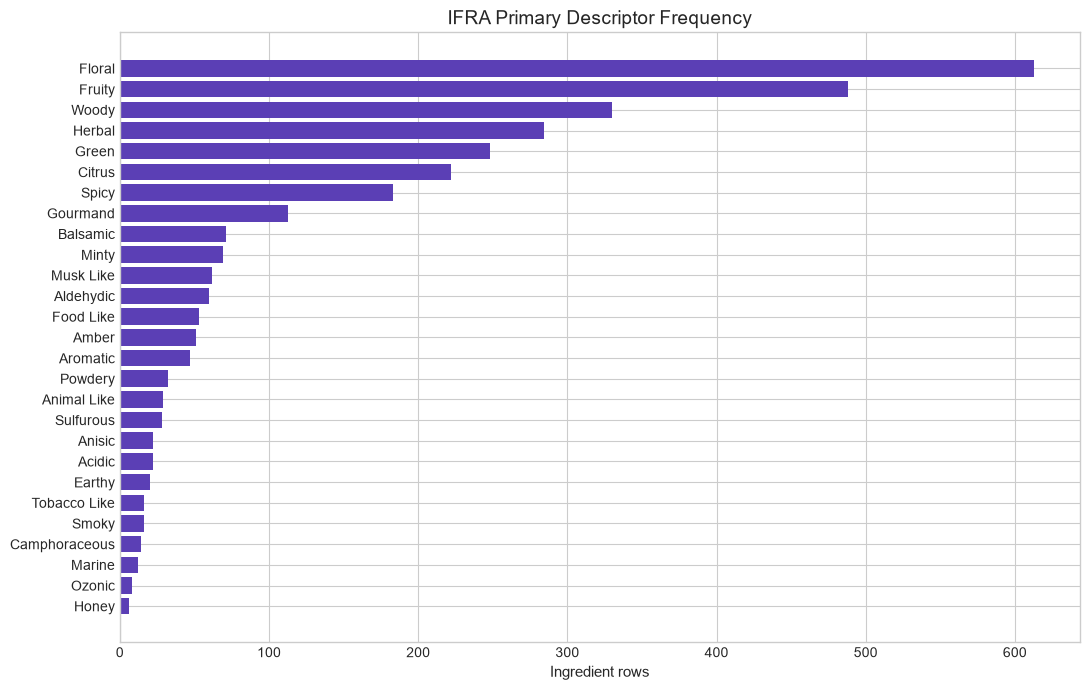

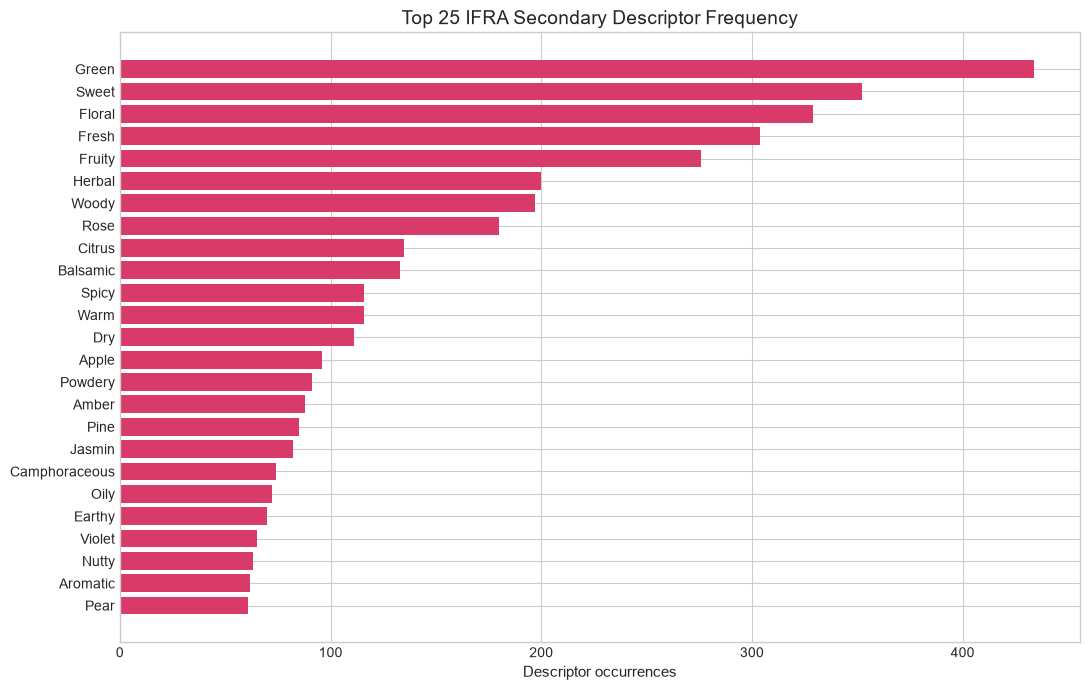

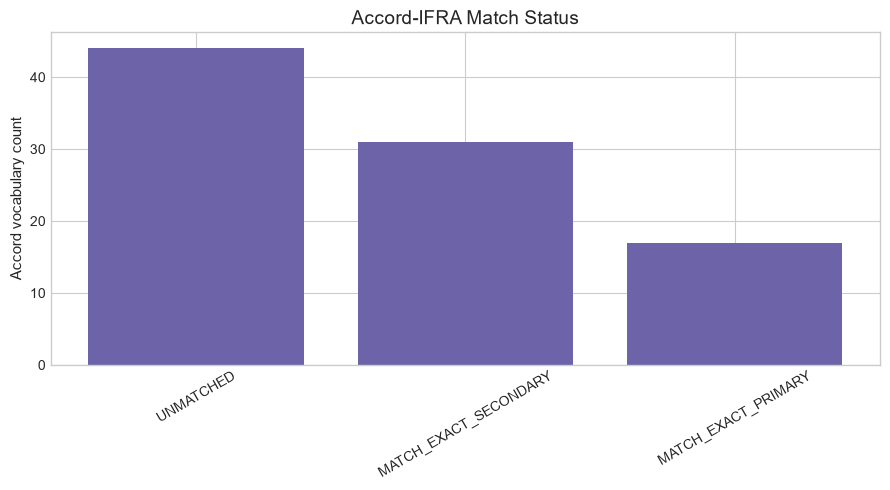

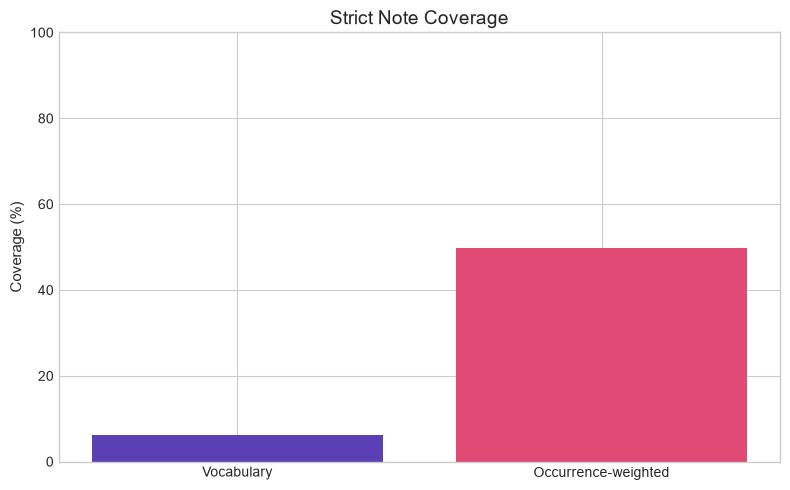

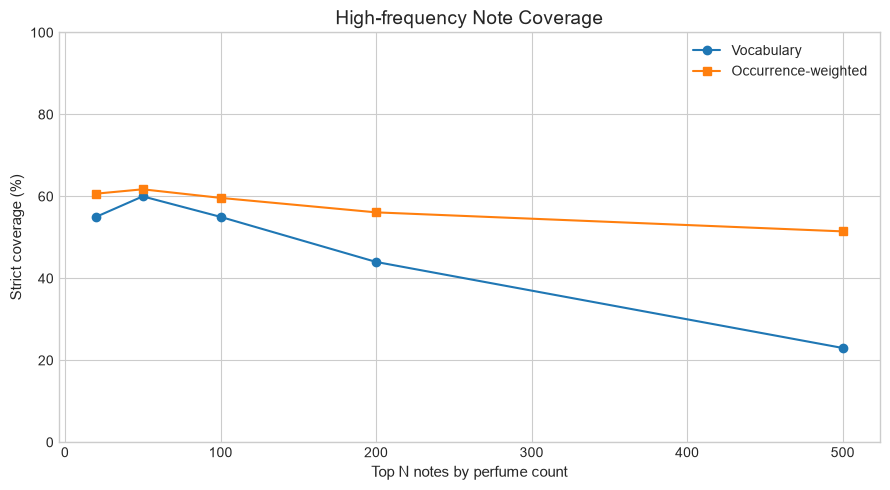

In [26]:
fig, axes = plt.subplots(1, 1, figsize=(11, 7))
plot_df = primary_distribution_df.sort_values("count")
axes.barh(plot_df["primary_descriptor"], plot_df["count"], color="#5B3FB5")
axes.set_title("IFRA Primary Descriptor Frequency")
axes.set_xlabel("Ingredient rows")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(11, 7))
plot_df = secondary_distribution_df.head(25).sort_values("count")
axes.barh(plot_df["secondary_descriptor"], plot_df["count"], color="#D83B69")
axes.set_title("Top 25 IFRA Secondary Descriptor Frequency")
axes.set_xlabel("Descriptor occurrences")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(9, 5))
status_counts = accord_matching_df["match_status"].value_counts()
axes.bar(status_counts.index, status_counts.values, color="#6C63A8")
axes.set_title("Accord-IFRA Match Status")
axes.set_ylabel("Accord vocabulary count")
axes.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(8, 5))
coverage_plot = pd.DataFrame({
    "Coverage": [strict_note_vocabulary_coverage, strict_note_occurrence_weighted_coverage],
}, index=["Vocabulary", "Occurrence-weighted"])
axes.bar(coverage_plot.index, coverage_plot["Coverage"] * 100, color=["#5B3FB5", "#E04B75"])
axes.set_ylim(0, 100)
axes.set_ylabel("Coverage (%)")
axes.set_title("Strict Note Coverage")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(9, 5))
axes.plot(top_note_coverage_df["top_n"], top_note_coverage_df["strict_vocabulary_coverage"] * 100, marker="o", label="Vocabulary")
axes.plot(top_note_coverage_df["top_n"], top_note_coverage_df["strict_occurrence_weighted_coverage"] * 100, marker="s", label="Occurrence-weighted")
axes.set_ylim(0, 100)
axes.set_xlabel("Top N notes by perfume count")
axes.set_ylabel("Strict coverage (%)")
axes.set_title("High-frequency Note Coverage")
axes.legend()
plt.tight_layout()
plt.show()


## 27. Save All Outputs


In [27]:
metrics = {
    "total_rows": len(ifra_df),
    "unique_cas": ifra_df["cas_number"].nunique(),
    "unique_principal_names": ifra_df["principal_name"].nunique(),
    "unique_primary_descriptors": ifra_df["primary_descriptor"].map(conservative_normalize).nunique(),
    "unique_secondary_descriptors": secondary_long_df["secondary_descriptor"].map(conservative_normalize).nunique(),
    "total_accords": total_accords,
    "strict_matched_accords": strict_matched_accords,
    "strict_accord_vocabulary_coverage": strict_accord_vocabulary_coverage,
    "potential_accord_coverage": potential_accord_coverage,
    "accord_occurrence_weighted_coverage": accord_occurrence_weighted_coverage,
    "total_notes": total_notes,
    "strict_matched_notes": strict_matched_notes,
    "strict_note_vocabulary_coverage": strict_note_vocabulary_coverage,
    "potential_note_coverage": potential_note_coverage,
    "strict_note_occurrence_weighted_coverage": strict_note_occurrence_weighted_coverage,
    "perfumes_with_at_least_one_strict_matched_note": perfumes_with_at_least_one_strict_matched_note,
    "perfume_level_note_coverage": perfume_level_note_coverage,
}
coverage_metrics_df = pd.DataFrame([{"metric": key, "value": value} for key, value in metrics.items()])
coverage_metrics_df.to_csv(OUTPUT_DIR / "17_ifra_coverage_metrics.csv", index=False, encoding="utf-8-sig")

readme_text = f"""# IFRA Fragrance Ingredient Glossary

Source: IFRA Fragrance Ingredient Glossary, April 2020 Edition, The International Fragrance Association.

> Information derived from the IFRA Fragrance Ingredient Glossary, developed by The International Fragrance Association.

## Files

- Raw PDF: `data/external/ifra/raw/ifra-fragrance-ingredient-glossary-april-2020.pdf`
- Processed ingredients: `data/external/ifra/processed/ifra_ingredients_2020.csv`
- Primary descriptor definitions: `data/external/ifra/processed/ifra_primary_descriptor_definitions_2020.csv`
- Extraction date: {dt.date.today().isoformat()}

## Columns

- `cas_number`: CAS number as printed; one row contains a parenthesized alternate CAS.
- `principal_name`: IFRA principal fragrance-ingredient name. A trailing PDF update marker (`*`) is removed.
- `primary_descriptor`: IFRA primary olfactory descriptor.
- `descriptor_2`, `descriptor_3`: additional co-occurring descriptors; their order is not interpreted as intensity.
- `source_page`: 1-based physical PDF page number.
- Definition data: `descriptor`, `definition`, `source_page`.

## Interpretation and use

This is fragrance-ingredient data, not a Fragrantica Note dictionary. A Fragrantica Note is a presentation concept and must not be assumed identical to an IFRA ingredient. Material-family and alias links in the analysis are candidates requiring manual review, not verified equivalence.

Before redistribution or public use, review the terms of use in the source PDF. The source states that use in whole or in part must credit The International Fragrance Association.
"""
(PROCESSED_DIR / "README.md").write_text(readme_text, encoding="utf-8")

primary_match_count = int((accord_matching_df["matched_ifra_level"] == "PRIMARY").sum())
secondary_match_count = int((accord_matching_df["matched_ifra_level"] == "SECONDARY").sum())
top_unmatched_lines = "\n".join(
    f"- {row.note}: {row.perfume_count:,} perfumes, {row.occurrence_count:,} occurrences"
    for row in top_unmatched_notes_df.head(15).itertuples(index=False)
)
top_n_lines = "\n".join(
    f"- Top {int(row.top_n)}: {row.strict_matched_notes}/{row.available_notes} ({row.strict_vocabulary_coverage:.1%}); occurrence-weighted {row.strict_occurrence_weighted_coverage:.1%}"
    for row in top_note_coverage_df.itertuples(index=False)
)

summary_text = f"""# IFRA Knowledge Coverage Analysis

## 결과 요약

IFRA 2020 Glossary에서 {metrics['total_rows']:,}개 ingredient 행, {metrics['unique_primary_descriptors']:,}개 Primary descriptor, {metrics['unique_secondary_descriptors']:,}개 Secondary descriptor를 추출했다. Fragrantica의 {metrics['total_accords']:,}개 Accord 중 strict vocabulary coverage는 {metrics['strict_accord_vocabulary_coverage']:.1%}, occurrence-weighted coverage는 {metrics['accord_occurrence_weighted_coverage']:.1%}였다. {metrics['total_notes']:,}개 Note 중 strict vocabulary coverage는 {metrics['strict_note_vocabulary_coverage']:.1%}, occurrence-weighted coverage는 {metrics['strict_note_occurrence_weighted_coverage']:.1%}, perfume-level coverage는 {metrics['perfume_level_note_coverage']:.1%}였다.

### 결론

IFRA는 **향의 저수준 olfactory descriptor와 ingredient 근거를 제공하는 보조 지식원**으로 가치가 있다. 다만 Fragrantica Note와 IFRA Ingredient는 다른 개념이므로 IFRA만으로 Note ontology를 완성했다고 볼 수 없다. strict match와 사람이 검토해야 할 material-family/alias candidate를 분리해야 하며, 추천 점수나 자연어 의미 변환에는 이 결과를 직접 사용하면 안 된다.

---

## 1. IFRA 데이터 구조

- Rows: {metrics['total_rows']:,}
- Unique CAS: {metrics['unique_cas']:,}
- Unique Principal Names: {metrics['unique_principal_names']:,}
- Primary Descriptor: {metrics['unique_primary_descriptors']:,}
- Secondary Descriptor: {metrics['unique_secondary_descriptors']:,}

## 2. IFRA Descriptor 구조

Primary descriptor는 27개 정의와 표의 vocabulary가 일치했다. Secondary descriptor는 훨씬 세분화된 재료·향조 표현을 포함한다. Primary-Secondary edge와 profile은 같은 ingredient 행에서의 동시 등장 근거이며 인과나 강도를 뜻하지 않는다.

## 3. Fragrantica Accord Coverage

- Strict: {metrics['strict_matched_accords']:,}/{metrics['total_accords']:,} ({metrics['strict_accord_vocabulary_coverage']:.1%})
- Potential (alias candidate 포함): {metrics['potential_accord_coverage']:.1%}
- Occurrence-weighted strict: {metrics['accord_occurrence_weighted_coverage']:.1%}
- Primary match: {primary_match_count:,}
- Secondary-only match: {secondary_match_count:,}

Secondary-only match가 {secondary_match_count:,}개이므로 Primary 27개만 사용하는 것보다 Secondary descriptor를 함께 보존하는 편이 직접 연결 범위를 넓힌다.

## 4. Fragrantica Note Coverage

- Vocabulary strict: {metrics['strict_matched_notes']:,}/{metrics['total_notes']:,} ({metrics['strict_note_vocabulary_coverage']:.1%})
- Potential (material family / alias candidate 포함): {metrics['potential_note_coverage']:.1%}
- Occurrence-weighted strict: {metrics['strict_note_occurrence_weighted_coverage']:.1%}
- Perfume-level strict: {metrics['perfumes_with_at_least_one_strict_matched_note']:,}/{total_perfumes:,} ({metrics['perfume_level_note_coverage']:.1%})

Potential coverage는 검증된 coverage가 아니라 사람이 검토할 수 있는 상한 후보이다.

## 5. 고빈도 Note Coverage

{top_n_lines}

## 6. 대표 Matching 사례

대표 사례는 `17_note_ifra_matching.csv`의 strict level, material-family candidate, alias candidate를 분리해 기록했다. `Pine -> Pine needle oil`, `Oud -> Agarwood`, `Cedar -> Cedarwood`, `Musk -> Musk Like` 같은 관계는 자동 정답이 아니라 수동 검토 후보이다.

## 7. 주요 Unmatched Note

{top_unmatched_lines}

## 8. IFRA의 장점

- 출처와 descriptor 정의가 명시된 ingredient-level olfactory vocabulary를 제공한다.
- Primary-Secondary 동시 등장 profile을 evidence로 보존할 수 있다.
- 고빈도 feature의 실제 사용 빈도와 결합하면 vocabulary coverage와 서비스 체감 coverage를 분리해 볼 수 있다.

## 9. IFRA의 한계

- Fragrantica Note concept와 IFRA ingredient는 동일하지 않다.
- Descriptor는 향수 ranking score나 배합 비율, 강도를 제공하지 않는다.
- Strict unmatched는 잘못된 Note라는 뜻이 아니라 IFRA에서 직접 연결 근거를 찾지 못했다는 뜻이다.
- Alias 및 material family 후보는 수동 검증 전 확정 mapping으로 사용할 수 없다.

## 10. Semantic Bridge 활용 가능성

이번 노트북은 Semantic Bridge를 구현하지 않았다. IFRA는 `ingredient -> primary/secondary descriptor` evidence layer로는 활용할 수 있지만, `비 오는 숲 -> woody/green/earthy` 같은 추상 자연어 mapping을 직접 보장하지 않는다. 향후 bridge에서는 IFRA edge를 하나의 근거로 사용하되 별도 자연어·전문 ontology 자료와 사람이 검증한 alias를 결합해야 한다.

## 11. 다음 단계 제안

1. `17_top_unmatched_notes.csv`의 고빈도 항목부터 외부 권위 자료(dsm-firmenich, IFF, Givaudan 등)의 보완 범위를 정한다.
2. `17_ifra_alias_candidates.csv`와 material-family candidate를 사람이 검토해 versioned mapping으로 분리한다.
3. 검증된 mapping만 이용해 별도 Semantic Bridge 실험을 설계하고, 추천 점수에는 독립적인 평가를 거친 뒤 사용한다.
"""
(OUTPUT_DIR / "17_ifra_knowledge_coverage_summary.md").write_text(summary_text, encoding="utf-8")

expected_outputs = [
    IFRA_CSV_PATH,
    DEFINITION_CSV_PATH,
    PROCESSED_DIR / "README.md",
    OUTPUT_DIR / "17_ifra_extraction_quality.csv",
    OUTPUT_DIR / "17_ifra_primary_descriptor_distribution.csv",
    OUTPUT_DIR / "17_ifra_secondary_descriptor_distribution.csv",
    OUTPUT_DIR / "17_ifra_descriptor_edges.csv",
    OUTPUT_DIR / "17_ifra_secondary_primary_profile.csv",
    OUTPUT_DIR / "17_fragrantica_accord_vocabulary.csv",
    OUTPUT_DIR / "17_fragrantica_note_vocabulary.csv",
    OUTPUT_DIR / "17_accord_ifra_matching.csv",
    OUTPUT_DIR / "17_note_ifra_matching.csv",
    OUTPUT_DIR / "17_ifra_alias_candidates.csv",
    OUTPUT_DIR / "17_ifra_coverage_metrics.csv",
    OUTPUT_DIR / "17_ifra_top_note_coverage.csv",
    OUTPUT_DIR / "17_top_unmatched_notes.csv",
    OUTPUT_DIR / "17_ifra_knowledge_coverage_summary.md",
]
missing_outputs = [path for path in expected_outputs if not path.exists()]
assert not missing_outputs, f"Missing outputs: {missing_outputs}"
print(f"Saved {len(expected_outputs)} requested output files.")


Saved 17 requested output files.


## 28. Final Summary


In [28]:
print("[IFRA]")
print(f"Total Rows: {metrics['total_rows']:,}")
print(f"Unique CAS: {metrics['unique_cas']:,}")
print(f"Unique Principal Names: {metrics['unique_principal_names']:,}")
print(f"Primary Descriptor Count: {metrics['unique_primary_descriptors']:,}")
print(f"Secondary Descriptor Count: {metrics['unique_secondary_descriptors']:,}")

print("\n[Accord Coverage]")
print(f"Total Accord: {metrics['total_accords']:,}")
print(f"Strict Matched: {metrics['strict_matched_accords']:,}")
print(f"Strict Vocabulary Coverage: {metrics['strict_accord_vocabulary_coverage']:.2%}")
print(f"Potential Coverage: {metrics['potential_accord_coverage']:.2%}")
print(f"Occurrence-weighted Coverage: {metrics['accord_occurrence_weighted_coverage']:.2%}")

print("\n[Note Coverage]")
print(f"Total Notes: {metrics['total_notes']:,}")
print(f"Strict Matched: {metrics['strict_matched_notes']:,}")
print(f"Strict Vocabulary Coverage: {metrics['strict_note_vocabulary_coverage']:.2%}")
print(f"Potential Coverage: {metrics['potential_note_coverage']:.2%}")
print(f"Occurrence-weighted Coverage: {metrics['strict_note_occurrence_weighted_coverage']:.2%}")
print(f"Perfume-level Coverage: {metrics['perfume_level_note_coverage']:.2%}")

print("\n[High Frequency Note Coverage]")
for row in top_note_coverage_df.itertuples(index=False):
    print(f"Top {int(row.top_n)}: {row.strict_vocabulary_coverage:.2%}")

print("\n[Output]")
for path in expected_outputs:
    print(path.relative_to(PROJECT_ROOT))


[IFRA]
Total Rows: 3,119
Unique CAS: 2,588
Unique Principal Names: 3,094
Primary Descriptor Count: 27
Secondary Descriptor Count: 228

[Accord Coverage]
Total Accord: 92
Strict Matched: 48
Strict Vocabulary Coverage: 52.17%
Potential Coverage: 55.43%
Occurrence-weighted Coverage: 74.08%

[Note Coverage]
Total Notes: 2,523
Strict Matched: 159
Strict Vocabulary Coverage: 6.30%
Potential Coverage: 10.31%
Occurrence-weighted Coverage: 49.70%
Perfume-level Coverage: 92.31%

[High Frequency Note Coverage]
Top 20: 55.00%
Top 50: 60.00%
Top 100: 55.00%
Top 200: 44.00%
Top 500: 23.00%

[Output]
data\external\ifra\processed\ifra_ingredients_2020.csv
data\external\ifra\processed\ifra_primary_descriptor_definitions_2020.csv
data\external\ifra\processed\README.md
analysis_outputs\17_ifra_extraction_quality.csv
analysis_outputs\17_ifra_primary_descriptor_distribution.csv
analysis_outputs\17_ifra_secondary_descriptor_distribution.csv
analysis_outputs\17_ifra_descriptor_edges.csv
analysis_outputs\17_i